# LLM-Judge Prompt Testing

Pull predictions from two existing MLflow runs (`few_shot_llm` and `metagente`),
join back to source code, and score them with a few candidate judge prompts to
compare how judge phrasing affects scores/agreement.


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
REPO_ROOT = "/home/phuc/code-sum"

RUN_IDS = {
    "few_shot_llm": "8ed48f980c5540e8b029056b268867e8",
    "few_shot_all_context": "7e938318a5974bcaaf0c424d43bae43e",
    "few_shot_all_context_4o": "81a2b718862c4b36aefdc0ec66dae63b",
    "agentic_rag": "b06fc2a80b074b94bd4ff88337950cbb",
    "zero_shot": "5987585716d54933b79acdbedaaaad15",
    "metagente": "512522dd8ba14ff4b8930906cea34a0f",

}

JUDGE_MODEL = "openai/gpt-4o-mini"
JUDGE_BACKEND = "openrouter"
JUDGE_TEMPERATURE = 0.0
JUDGE_MAX_TOKENS = 300
MAX_CONCURRENCY = 10

N_SAMPLES = 30  # sampled per run, then judged under every prompt variant below
RANDOM_SEED = 0


In [3]:
import asyncio
import json
import random
import re

import mlflow
import pandas as pd
from mlflow import MlflowClient
from tqdm.asyncio import tqdm as atqdm

from mas_code_sum.methods.llm_client import make_clients

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()


/home/phuc/code-sum/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load predictions from MLflow runs

Each run logged a `predictions/*.csv` artifact with columns
`id, project, func_name, run, reference, prediction`. `id` is the row index into
`dataset/full/test.jsonl`, so we can join the original code back in.


In [4]:
def load_predictions(run_name: str, run_id: str) -> pd.DataFrame:
    local_dir = client.download_artifacts(run_id, "predictions")
    csvs = list(pathlib.Path(local_dir).glob("*.csv"))
    assert len(csvs) == 1, f"expected exactly one predictions csv, found {csvs}"
    df = pd.read_csv(csvs[0])
    df["system"] = run_name
    return df


import pathlib

pred_dfs = {name: load_predictions(name, run_id) for name, run_id in RUN_IDS.items()}
for name, df in pred_dfs.items():
    print(name, df.shape)


few_shot_llm (200, 7)
few_shot_all_context (200, 7)
few_shot_all_context_4o (200, 7)
agentic_rag (200, 7)
zero_shot (200, 7)
metagente (200, 7)


In [5]:
# ── Join source code back in via dataset/full/test.jsonl (indexed by `id`) ──
from mas_code_sum.data import dataset_dir

_code_by_id: dict[int, str] = {}
with open(dataset_dir() / "full" / "test.jsonl") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        sample = json.loads(line)
        _code_by_id[sample["id"]] = sample["code"]

for name, df in pred_dfs.items():
    df["code"] = df["id"].map(_code_by_id)
    missing = df["code"].isna().sum()
    if missing:
        print(f"{name}: {missing} rows with no matching code (dropping)")
    pred_dfs[name] = df.dropna(subset=["code"]).reset_index(drop=True)


In [6]:
# ── Sample rows to judge ──────────────────────────────────────────────────
random.seed(RANDOM_SEED)

sampled_rows = []
for name, df in pred_dfs.items():
    n = min(N_SAMPLES, len(df))
    sampled_rows.append(df.sample(n=n, random_state=RANDOM_SEED))

judge_input_df = pd.concat(sampled_rows, ignore_index=True)
print(f"{len(judge_input_df)} (system, sample) pairs to judge")
judge_input_df.head()


180 (system, sample) pairs to judge


,id,project,func_name,run,reference,prediction,system,code
0,218,apache/airflow,DagRun.get_previous_dagrun,0,The previous DagRun if there is one,Get the previous DagRun for this DAG .,few_shot_llm,"def get_previous_dagrun(self, session=None):\n..."
1,1820,tamboui/tamboui,Monthly.of,0,Creates a calendar for the month containing th...,Here's a summary of the provided code snippets:,few_shot_llm,public static Monthly of(LocalDate displayDate...
2,1607,newton-physics/newton,ViewerBase._qualify,0,Prefix a backend object name with the active l...,Qualify a name with the active layer's prefix .,few_shot_llm,"def _qualify(self, name: str | None) -> str | ..."
3,548,orientechnologies/orientdb,ONodeManager.initCheckLeader,0,init the procedure that sends pings to other s...,Initializes the check leader thread.,few_shot_llm,private void initCheckLeader() {\n checkerT...
4,1827,tamboui/tamboui,ApiLevelsSnippets.inlineTuiRunnerBasic,0,========== INLINE TUI RUNNER ==========,Runs the demo application.,few_shot_llm,void inlineTuiRunnerBasic() throws Exception {...


## Candidate judge prompts

Each entry is a template with `{code}`, `{reference}`, `{prediction}` placeholders.
The judge must reply with a line like `Score: <1-5>` so we can parse it; add/edit
variants here to compare.


In [7]:
JUDGE_PROMPTS = {
    "reference_based_v1": '''You are evaluating an automatically generated summary of a code function.

Code:
{code}

Reference summary (written by a human):
{reference}

Candidate summary (written by a model):
{prediction}

Rate how well the candidate summary conveys the same meaning as the reference \
summary, on a scale from 1 (unrelated/incorrect) to 5 (equivalent in meaning).
Respond with a short justification, then a final line exactly of the form:
Score: <1-5>''',

    "reference_free_v1": '''You are evaluating whether a summary accurately and \
concisely describes what the following code does. Judge the summary on its own \
merits against the code -- do not penalize it for differing in wording from any \
particular reference.

Code:
{code}

Candidate summary:
{prediction}

Rate the summary's accuracy and completeness from 1 (misleading/incorrect) to \
5 (accurate and complete). Respond with a short justification, then a final \
line exactly of the form:
Score: <1-5>''',

    "pairwise_criteria_v1": '''Evaluate the candidate summary of the code below \
against three criteria: (1) correctness -- does it accurately describe the \
code's behavior, (2) completeness -- does it capture the important side \
effects/return value, (3) concision -- is it free of irrelevant detail.

Code:
{code}

Reference summary:
{reference}

Candidate summary:
{prediction}

Score the candidate from 1-5 overall, weighing all three criteria. Respond with \
a short justification, then a final line exactly of the form:
Score: <1-5>''',

    "context_aware_v1": '''You are evaluating an automatically generated summary of a code function. \
You are shown the isolated function body below, but the model that produced \
the candidate summary additionally had access to file-level context (module \
docstring, enclosing class, other functions in the same file) which is \
reproduced here. The candidate may correctly reference details from this \
context even though they are not visible in the isolated function body -- do \
not penalize it for that. Only penalize claims that are unsupported even by \
this additional context, or that contradict the code.

File context:
{file_context}

Code:
{code}

Reference summary (written by a human):
{reference}

Candidate summary (written by a model):
{prediction}

Rate how well the candidate summary conveys the same meaning as the reference \
summary, on a scale from 1 (unrelated/incorrect) to 5 (equivalent in meaning).
Respond with a short justification, then a final line exactly of the form:
Score: <1-5>''',
}

# The first judge run (below) only covers these three -- context_aware_v1 needs
# a "file_context" column, added to its own input frame later in the notebook.
INITIAL_PROMPT_NAMES = ["reference_based_v1", "reference_free_v1", "pairwise_criteria_v1"]


## Run the judge

Same client/retry plumbing as the rest of the project (`make_clients`), called
once per (sample, prompt variant) pair with bounded concurrency.


In [8]:
_SCORE_RE = re.compile(r"Score:\s*([1-5])", re.IGNORECASE)


def parse_score(judge_output: str) -> int | None:
    match = _SCORE_RE.search(judge_output)
    return int(match.group(1)) if match else None


_, async_client = make_clients(JUDGE_BACKEND)
_sem = asyncio.Semaphore(MAX_CONCURRENCY)


async def judge_one(prompt_template: str, row: pd.Series) -> dict:
    prompt = prompt_template.format(
        code=row["code"],
        reference=row["reference"],
        prediction=row["prediction"],
    )
    async with _sem:
        response = await async_client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=JUDGE_TEMPERATURE,
            max_tokens=JUDGE_MAX_TOKENS,
        )
    text = response.choices[0].message.content
    return {"judge_output": text, "score": parse_score(text)}


In [9]:
async def run_judge_grid(df: pd.DataFrame, prompts: dict[str, str]) -> pd.DataFrame:
    tasks = []
    task_meta = []
    for prompt_name, template in prompts.items():
        for _, row in df.iterrows():
            tasks.append(judge_one(template, row))
            task_meta.append({
                "prompt_name": prompt_name,
                "system": row["system"],
                "id": row["id"],
                "project": row["project"],
                "func_name": row["func_name"],
            })

    results = await atqdm.gather(*tasks, desc="judging")

    out_rows = [{**meta, **res} for meta, res in zip(task_meta, results)]
    return pd.DataFrame(out_rows)


judge_results = await run_judge_grid(
    judge_input_df, {name: JUDGE_PROMPTS[name] for name in INITIAL_PROMPT_NAMES}
)
judge_results.head()


judging: 100%|██████████| 540/540 [02:54<00:00,  3.10it/s]


,prompt_name,system,id,project,func_name,judge_output,score
0,reference_based_v1,few_shot_llm,218,apache/airflow,DagRun.get_previous_dagrun,The candidate summary captures the essence of ...,4.0
1,reference_based_v1,few_shot_llm,1820,tamboui/tamboui,Monthly.of,The candidate summary does not convey any spec...,1.0
2,reference_based_v1,few_shot_llm,1607,newton-physics/newton,ViewerBase._qualify,The candidate summary captures the essence of ...,4.0
3,reference_based_v1,few_shot_llm,548,orientechnologies/orientdb,ONodeManager.initCheckLeader,"The candidate summary ""Initializes the check l...",3.0
4,reference_based_v1,few_shot_llm,1827,tamboui/tamboui,ApiLevelsSnippets.inlineTuiRunnerBasic,"The candidate summary ""Runs the demo applicati...",2.0


## Compare prompt variants

Mean score per (prompt, system), plus how often each prompt variant failed to
produce a parseable score.


In [10]:
summary = judge_results.groupby(["prompt_name", "system"])["score"].agg(["mean", "count"])
print(summary)

parse_failures = judge_results["score"].isna().groupby(judge_results["prompt_name"]).sum()
print("\nunparseable outputs per prompt:")
print(parse_failures)


                                                  mean  count
prompt_name          system                                  
pairwise_criteria_v1 agentic_rag              3.433333     30
                     few_shot_all_context     2.466667     30
                     few_shot_all_context_4o  3.344828     29
                     few_shot_llm             2.233333     30
                     metagente                2.866667     30
                     zero_shot                2.800000     30
reference_based_v1   agentic_rag              4.133333     30
                     few_shot_all_context     3.466667     30
                     few_shot_all_context_4o  4.166667     30
                     few_shot_llm             3.033333     30
                     metagente                3.733333     30
                     zero_shot                3.600000     30
reference_free_v1    agentic_rag              3.900000     30
                     few_shot_all_context     3.166667     30
        

In [11]:
# ── Inspect disagreement between prompt variants on the same sample ─────────
pivot = judge_results.pivot_table(index=["system", "id"], columns="prompt_name", values="score")
pivot["spread"] = pivot.max(axis=1) - pivot.min(axis=1)
pivot.sort_values("spread", ascending=False).head(10)


prompt_name                pairwise_criteria_v1  reference_based_v1  \
system               id                                               
metagente            1809                   5.0                 2.0   
agentic_rag          205                    2.0                 4.0   
                     1623                   3.0                 5.0   
                     207                    2.0                 4.0   
few_shot_all_context 1646                   2.0                 4.0   
                     511                    3.0                 5.0   
                     1625                   2.0                 4.0   
                     1622                   2.0                 4.0   
                     237                    2.0                 4.0   
                     510                    2.0                 4.0   

prompt_name                reference_free_v1  spread  
system               id                               
metagente            1809                4.0     3.0  
agentic_rag          205                 3.0     2.0  
                     1623                4.0     2.0  
                     207                 4.0     2.0  
few_shot_all_context 1646                4.0     2.0  
                     511                 3.0     2.0  
                     1625                3.0     2.0  
                     1622                3.0     2.0  
                     237                 4.0     2.0  
                     510                 3.0     2.0

In [12]:
# Spot-check a specific disagreement: pull code/reference/prediction + all judge outputs
row_id = pivot.sort_values('spread', ascending=False).sample().index[0]
system, sample_id = row_id
sample_row = judge_input_df[(judge_input_df["system"] == system) & (judge_input_df["id"] == sample_id)].iloc[0]
print(sample_row["code"])
print("\nreference:", sample_row["reference"])
print("prediction:", sample_row["prediction"])
print()
for _, r in judge_results[(judge_results["system"] == system) & (judge_results["id"] == sample_id)].iterrows():
    print(f"--- {r['prompt_name']} (score={r['score']}) ---")
    print(r["judge_output"])
    print()


def get_previous_dagrun(self, session=None):
        """The previous DagRun, if there is one"""

        return session.query(DagRun).filter(
            DagRun.dag_id == self.dag_id,
            DagRun.execution_date < self.execution_date
        ).order_by(
            DagRun.execution_date.desc()
        ).first()

reference: The previous DagRun if there is one
prediction: Retrieves the previous DAG run with a later execution date.

--- reference_based_v1 (score=1.0) ---
The candidate summary inaccurately states that it retrieves a previous DAG run with a "later execution date," which contradicts the function's purpose of finding a previous run with an "earlier execution date." The reference summary correctly indicates that it retrieves the previous DagRun if one exists, without any misleading implications about the execution date. Therefore, the candidate summary does not convey the same meaning as the reference summary.

Score: 1

--- reference_free_v1 (score=1.0) ---
The candidat

## Compute BLEU

Per-sample BLEU (same smoothed corpus-BLEU-4 formula the project logs to
MLflow, inlined here so the notebook stays import-free), reported alongside
the judge score as a separate, standalone metric -- not cross-compared against
it.


In [13]:
import sys
# ── Inlined smoothed BLEU (same formula as mas_code_sum.evaluator.bleu) ─────
import math
import xml.sax.saxutils

_normalize1 = [
    (re.compile(r"<skipped>"), ""),
    (re.compile(r"-\n"), ""),
    (re.compile(r"\n"), " "),
]
_normalize2 = [
    (re.compile(r"([\{-\~\[-\` -\&\(-\+\:-\@\/])"), r" \1 "),
    (re.compile(r"([^0-9])([\.,])"), r"\1 \2 "),
    (re.compile(r"([\.,])([^0-9])"), r" \1 \2"),
    (re.compile(r"([0-9])(-)"), r"\1 \2 "),
]


def _normalize(s):
    if not isinstance(s, str):
        s = " ".join(s)
    for pattern, replace in _normalize1:
        s = pattern.sub(replace, s)
    s = xml.sax.saxutils.unescape(s, {"&quot;": '"'})
    s = " %s " % s
    s = s.lower()
    for pattern, replace in _normalize2:
        s = pattern.sub(replace, s)
    return s.split()


def _count_ngrams(words, n=4):
    counts = {}
    for k in range(1, n + 1):
        for i in range(len(words) - k + 1):
            ngram = tuple(words[i : i + k])
            counts[ngram] = counts.get(ngram, 0) + 1
    return counts


def _cook_refs(refs, n=4):
    refs = [_normalize(ref) for ref in refs]
    maxcounts = {}
    for ref in refs:
        counts = _count_ngrams(ref, n)
        for ngram, count in counts.items():
            maxcounts[ngram] = max(maxcounts.get(ngram, 0), count)
    return [len(ref) for ref in refs], maxcounts


def _cook_test(test, item, n=4):
    reflens, refmaxcounts = item
    test = _normalize(test)
    result = {"testlen": len(test), "reflen": min(reflens)}
    result["guess"] = [max(len(test) - k + 1, 0) for k in range(1, n + 1)]
    result["correct"] = [0] * n
    counts = _count_ngrams(test, n)
    for ngram, count in counts.items():
        result["correct"][len(ngram) - 1] += min(refmaxcounts.get(ngram, 0), count)
    return result


def _score_cooked(comps, n=4):
    logbleu = 0.0
    for k in range(n):
        correct = comps["correct"][k]
        guess = comps["guess"][k]
        addsmooth = 1 if k > 0 else 0
        logbleu += math.log(correct + addsmooth + sys.float_info.min) - math.log(guess + addsmooth + sys.float_info.min)
    logbleu /= float(n)
    brev_penalty = min(0, 1 - float(comps["reflen"] + 1) / (comps["testlen"] + 1))
    return math.exp(logbleu + brev_penalty)


def sentence_bleu(reference: str, candidate: str) -> float:
    """Smoothed corpus-style BLEU-4 for a single (reference, candidate) pair, 0-100 scale."""
    item = _cook_refs([reference])
    comps = _cook_test(candidate, item)
    return _score_cooked(comps) * 100


In [14]:
# ── Compute BLEU per sampled row, join onto judge_results ───────────────────
judge_input_df["bleu"] = judge_input_df.apply(
    lambda row: sentence_bleu(row["reference"], row["prediction"]), axis=1
)

judge_results = judge_results.merge(
    judge_input_df[["system", "id", "bleu"]],
    on=["system", "id"],
    how="left",
)
judge_results.head()


,prompt_name,system,id,project,func_name,judge_output,score,bleu
0,reference_based_v1,few_shot_llm,218,apache/airflow,DagRun.get_previous_dagrun,The candidate summary captures the essence of ...,4.0,2.860624e+01
1,reference_based_v1,few_shot_llm,1820,tamboui/tamboui,Monthly.of,The candidate summary does not convey any spec...,1.0,8.789051e+00
2,reference_based_v1,few_shot_llm,1607,newton-physics/newton,ViewerBase._qualify,The candidate summary captures the essence of ...,4.0,3.249905e+01
3,reference_based_v1,few_shot_llm,548,orientechnologies/orientdb,ONodeManager.initCheckLeader,"The candidate summary ""Initializes the check l...",3.0,4.769377e+00
4,reference_based_v1,few_shot_llm,1827,tamboui/tamboui,ApiLevelsSnippets.inlineTuiRunnerBasic,"The candidate summary ""Runs the demo applicati...",2.0,1.461074e-77


## Compare the two runs (few_shot_llm vs. metagente)

Both runs predicted on the same 200 test samples in the same order, and
`judge_input_df` sampled both with the same `random_state`, so the sampled
`id`s line up 1:1 across systems -- this lets us do a paired, per-sample
comparison rather than just comparing independent means.


In [15]:
# ── Aggregate judge score + BLEU per system ──────────────────────────────────
system_summary = judge_results.groupby(["prompt_name", "system"]).agg(
    mean_score=("score", "mean"),
    mean_bleu=("bleu", "mean"),
    n=("score", "size"),
)
system_summary


mean_score  mean_bleu   n
prompt_name          system                                            
pairwise_criteria_v1 agentic_rag                3.433333  13.924404  30
                     few_shot_all_context       2.466667  24.326172  30
                     few_shot_all_context_4o    3.344828  16.800095  30
                     few_shot_llm               2.233333  18.650775  30
                     metagente                  2.866667  12.851975  30
                     zero_shot                  2.800000  13.805088  30
reference_based_v1   agentic_rag                4.133333  13.924404  30
                     few_shot_all_context       3.466667  24.326172  30
                     few_shot_all_context_4o    4.166667  16.800095  30
                     few_shot_llm               3.033333  18.650775  30
                     metagente                  3.733333  12.851975  30
                     zero_shot                  3.600000  13.805088  30
reference_free_v1    agentic_rag                3.900000  13.924404  30
                     few_shot_all_context       3.166667  24.326172  30
                     few_shot_all_context_4o    3.900000  16.800095  30
                     few_shot_llm               2.866667  18.650775  30
                     metagente                  3.633333  12.851975  30
                     zero_shot                  3.600000  13.805088  30

In [16]:
# ── Paired per-sample deltas (metagente - few_shot_llm) ──────────────────────
paired = judge_results.pivot_table(index=["prompt_name", "id"], columns="system", values="score")
paired["score_delta"] = paired["metagente"] - paired["few_shot_llm"]
paired.head()


system                    agentic_rag  few_shot_all_context  \
prompt_name          id                                       
pairwise_criteria_v1 205          2.0                   2.0   
                     207          2.0                   3.0   
                     212          4.0                   2.0   
                     218          4.0                   3.0   
                     233          3.0                   2.0   

system                    few_shot_all_context_4o  few_shot_llm  metagente  \
prompt_name          id                                                      
pairwise_criteria_v1 205                      3.0           3.0        3.0   
                     207                      3.0           2.0        3.0   
                     212                      3.0           2.0        2.0   
                     218                      4.0           3.0        4.0   
                     233                      3.0           2.0        2.0   

system                    zero_shot  score_delta  
prompt_name          id                           
pairwise_criteria_v1 205        2.0          0.0  
                     207        3.0          1.0  
                     212        2.0          0.0  
                     218        1.0          1.0  
                     233        2.0          0.0

In [17]:
# ── Win rate: how often does metagente score higher than few_shot_llm? ──────
win_rate = (
    paired.groupby("prompt_name")["score_delta"]
    .apply(lambda d: pd.Series({
        "metagente_wins": (d > 0).mean(),
        "ties": (d == 0).mean(),
        "few_shot_llm_wins": (d < 0).mean(),
        "mean_delta": d.mean(),
    }))
    .unstack()
)
win_rate


,metagente_wins,ties,few_shot_llm_wins,mean_delta
prompt_name,,,,
pairwise_criteria_v1,0.5,0.433333,0.066667,0.633333
reference_based_v1,0.5,0.433333,0.066667,0.700000
reference_free_v1,0.6,0.400000,0.000000,0.766667


### Significance of the judge-score gap

Wilcoxon signed-rank test on the paired per-sample score deltas, per prompt
variant -- tests whether metagente's edge (or few_shot_llm's) is unlikely to be
noise given this sample size.


In [18]:
from scipy.stats import wilcoxon

for prompt_name, group in paired.groupby("prompt_name"):
    deltas = group["score_delta"]
    if (deltas != 0).sum() == 0:
        print(f"{prompt_name}: all ties, cannot run Wilcoxon")
        continue
    stat, p = wilcoxon(deltas)
    print(f"{prompt_name}: mean_delta={deltas.mean():+.2f}  wilcoxon p={p:.4f}")


pairwise_criteria_v1: mean_delta=+0.63  wilcoxon p=0.0015
reference_based_v1: mean_delta=+0.70  wilcoxon p=0.0016
reference_free_v1: mean_delta=+0.77  wilcoxon p=0.0001


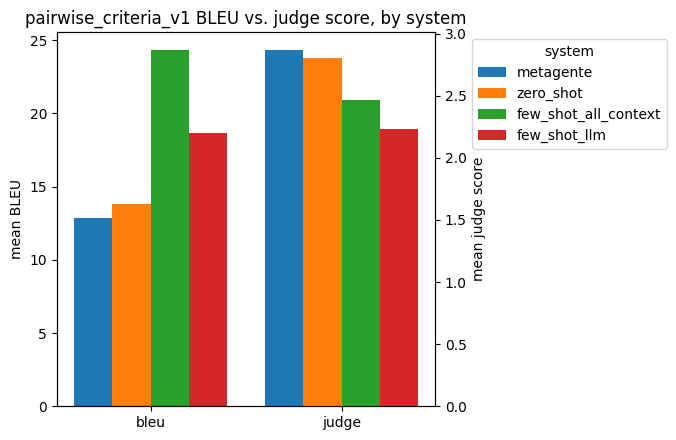

In [34]:
import matplotlib.pyplot as plt

# ── Single plot: pairwise_criteria_v1 BLEU vs. judge score, colored by system ──
SYSTEMS_TO_PLOT = ["few_shot_llm", "metagente", "few_shot_all_context", "zero_shot"] 

pairwise = system_summary.loc["pairwise_criteria_v1"].sort_values("mean_score", ascending=False)
if SYSTEMS_TO_PLOT is not None:
    pairwise = pairwise.loc[[s for s in pairwise.index if s in SYSTEMS_TO_PLOT]]

systems = list(pairwise.index)
colors = plt.cm.tab10.colors

fig, ax_bleu = plt.subplots(figsize=(7, 4.5))
ax_score = ax_bleu.twinx()

n = len(systems)
width = 0.8 / n
group_x = {"bleu": 0, "judge": 1}

for i, system in enumerate(systems):
    offset = (i - (n - 1) / 2) * width
    color = colors[i % len(colors)]
    ax_bleu.bar(group_x["bleu"] + offset, pairwise.loc[system, "mean_bleu"], width, color=color, label=system)
    ax_score.bar(group_x["judge"] + offset, pairwise.loc[system, "mean_score"], width, color=color)

ax_bleu.set_xticks(list(group_x.values()))
ax_bleu.set_xticklabels(list(group_x.keys()))
ax_bleu.set_ylabel("mean BLEU")
ax_score.set_ylabel("mean judge score")
ax_bleu.set_title("pairwise_criteria_v1 BLEU vs. judge score, by system")
ax_bleu.legend(title="system", loc="upper left", bbox_to_anchor=(1.08, 1))

fig.tight_layout()
plt.show()

## Fixing a judge blind spot: `few_shot_all_context` sees more than the judge does

`few_shot_all_context` additionally feeds the model module docstring / enclosing
class / sibling-function outline for each sample (see
`enrichers/file_context.py`), so its predictions can correctly reference things
that aren't visible in the isolated function body the judge has been shown so
far. A judge that only sees `code` will read those references as unsupported
and mark the summary down -- penalizing it for using information it was
legitimately given, not for being wrong.

The fix (prompt `context_aware_v1`, defined in the consolidated prompts cell
above): reconstruct the exact same context block (module doc / class / import
/ sibling outline) via the project's own extraction logic -- re-deriving it by
hand here would drift from what the method actually saw -- and give it to the
judge for every system, since the context is a property of the file location,
not of which method generated the prediction. That keeps the comparison fair
across all three systems rather than just papering over `all_context`'s score.


In [49]:
# ── Reuse the project's own file-context extraction (not reimplemented, to avoid drift) ──
import sys as _sys

_SRC_PATH = str(pathlib.Path(REPO_ROOT) / "src")
if _SRC_PATH not in _sys.path:
    _sys.path.insert(0, _SRC_PATH)

from mas_code_sum.enrichers.file_context import (
    _extract_func_name_from_code,
    extract_file_context,
    extract_file_outline,
    render_file_context,
)
from mas_code_sum.enrichers.file_context_java import _extract_method_name_from_code as _extract_java_method_name


In [50]:
# ── Load full per-id metadata (path/language/blame_sha) needed for context extraction ──
_meta_by_id: dict[int, dict] = {}
with open(pathlib.Path(REPO_ROOT) / "dataset" / "full" / "test.jsonl") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        s = json.loads(line)
        _meta_by_id[s["id"]] = {
            "repo": s["repo"],
            "path": s["path"],
            "language": s["language"],
            "blame_sha": s.get("blame_sha"),
        }


In [51]:
# ── Reconstruct the same context block few_shot_all_context injected ────────
# Matches that run's actual config: use_outer_context=True, use_class_context=True,
# use_repo=False (no repo description line), max_imports=0 (imports excluded),
# max_file_chars=4000.
from functools import lru_cache


@lru_cache(maxsize=None)
def build_file_context_block(sample_id: int) -> str:
    meta = _meta_by_id[sample_id]
    repo, path, language, blame_sha = meta["repo"], meta["path"], meta["language"], meta["blame_sha"]
    code_ = _code_by_id[sample_id]

    if language not in ("python", "java") or not repo or not path:
        return ""

    func_name = _extract_java_method_name(code_) if language == "java" else _extract_func_name_from_code(code_)

    parts = [f"Repository: {repo}", f"File: {path}"]

    ctx = extract_file_context(repo, path, code=code_, max_imports=0, language=language, sha=blame_sha)
    rendered = render_file_context(ctx)
    if rendered:
        parts.append(rendered)

    outline = extract_file_outline(
        repo, path, exclude_func_name=func_name, language=language, max_chars=4000, sha=blame_sha
    )
    if outline:
        parts.append(f"Other functions in file:\n{outline}")

    return "\n".join(parts)


In [52]:
# ── Load few_shot_all_context predictions for the same 30 sampled ids ───────
ALL_CONTEXT_RUN_ID = "7e938318a5974bcaaf0c424d43bae43e"

all_context_df = load_predictions("few_shot_all_context", ALL_CONTEXT_RUN_ID)
all_context_df["code"] = all_context_df["id"].map(_code_by_id)

sample_ids = judge_input_df["id"].unique()
all_context_sample = all_context_df[all_context_df["id"].isin(sample_ids)].reset_index(drop=True)
print(f"{len(all_context_sample)} few_shot_all_context rows matched to the existing sample ids")


30 few_shot_all_context rows matched to the existing sample ids


In [53]:
# ── Attach the reconstructed context to every system's rows for the same ids ──
# (RUN_IDS may already include few_shot_all_context upstream -- drop any such rows
# from judge_input_df first so all_context_sample isn't duplicated below.)
context_input_df = pd.concat([
    judge_input_df[judge_input_df["system"] != "few_shot_all_context"][["id", "project", "func_name", "reference", "prediction", "system", "code"]],
    all_context_sample[["id", "project", "func_name", "reference", "prediction", "system", "code"]],
], ignore_index=True)

context_input_df["file_context"] = context_input_df["id"].map(build_file_context_block)
context_input_df["bleu"] = context_input_df.apply(lambda row: sentence_bleu(row["reference"], row["prediction"]), axis=1)

print(context_input_df["system"].value_counts())
context_input_df[context_input_df["system"] == "few_shot_all_context"][["id", "file_context"]].head(2)


system
few_shot_llm               30
few_shot_all_context_4o    30
agentic_rag                30
zero_shot                  30
metagente                  30
few_shot_all_context       30
Name: count, dtype: int64


,id,file_context
150,205,Repository: apache/airflow\nFile: airflow/cont...
151,207,Repository: apache/airflow\nFile: airflow/cont...


In [54]:
# ── Run context_aware_v1 for all three systems on the same 30 ids ───────────
async def judge_one_context_aware(row: dict) -> dict:
    prompt = JUDGE_PROMPTS["context_aware_v1"].format(
        file_context=row["file_context"] or "(no additional context available for this file)",
        code=row["code"],
        reference=row["reference"],
        prediction=row["prediction"],
    )
    async with _sem:
        response = await async_client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=JUDGE_TEMPERATURE,
            max_tokens=JUDGE_MAX_TOKENS,
        )
    text = response.choices[0].message.content
    return {"judge_output": text, "score": parse_score(text)}


_context_rows_meta = context_input_df.to_dict("records")
_context_tasks = [judge_one_context_aware(row) for row in _context_rows_meta]
_context_results = await atqdm.gather(*_context_tasks, desc="judging (context-aware)")

context_judge_results = pd.DataFrame([
    {
        "prompt_name": "context_aware_v1",
        "system": meta["system"],
        "id": meta["id"],
        "project": meta["project"],
        "func_name": meta["func_name"],
        "bleu": meta["bleu"],
        **res,
    }
    for meta, res in zip(_context_rows_meta, _context_results)
])

judge_results = pd.concat([judge_results, context_judge_results], ignore_index=True)
context_judge_results.groupby("system")["score"].mean()


judging (context-aware): 100%|██████████| 180/180 [00:42<00:00,  4.28it/s]


system
agentic_rag                4.600000
few_shot_all_context       3.900000
few_shot_all_context_4o    4.733333
few_shot_llm               3.366667
metagente                  4.166667
zero_shot                  4.000000
Name: score, dtype: float64

### Baseline: judge `few_shot_all_context` with the *original* (context-blind) prompt

`reference_based_v1` was never run against `few_shot_all_context` predictions
-- only `few_shot_llm` and `metagente` were judged with it. Run it once against
the same 30 `few_shot_all_context` samples so there's a real before/after
(same prompt family, only the context block added or withheld) instead of
comparing across systems that were never judged the same way.


In [55]:
async def judge_one(prompt_template: str, row: dict) -> dict:
    prompt = prompt_template.format(
        code=row["code"],
        reference=row["reference"],
        prediction=row["prediction"],
    )
    async with _sem:
        response = await async_client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=JUDGE_TEMPERATURE,
            max_tokens=JUDGE_MAX_TOKENS,
        )
    text = response.choices[0].message.content
    return {"judge_output": text, "score": parse_score(text)}


_baseline_rows_meta = all_context_sample.to_dict("records")
_baseline_tasks = [judge_one(JUDGE_PROMPTS["reference_based_v1"], row) for row in _baseline_rows_meta]
_baseline_results = await atqdm.gather(*_baseline_tasks, desc="judging (context-blind baseline)")

baseline_all_context_results = pd.DataFrame([
    {
        "prompt_name": "reference_based_v1",
        "system": meta["system"],
        "id": meta["id"],
        "project": meta["project"],
        "func_name": meta["func_name"],
        "bleu": sentence_bleu(meta["reference"], meta["prediction"]),
        **res,
    }
    for meta, res in zip(_baseline_rows_meta, _baseline_results)
])

# RUN_IDS may already include few_shot_all_context upstream, in which case the
# initial judge run already scored it under reference_based_v1 -- drop those
# rows first so this baseline rerun doesn't duplicate them.
judge_results = judge_results[
    ~((judge_results["system"] == "few_shot_all_context") & (judge_results["prompt_name"] == "reference_based_v1"))
]
judge_results = pd.concat([judge_results, baseline_all_context_results], ignore_index=True)
baseline_all_context_results["score"].mean()


judging (context-blind baseline): 100%|██████████| 30/30 [00:07<00:00,  3.99it/s]


np.float64(3.5)

### Did giving the judge the context change `few_shot_all_context`'s score?

Same prompt family (`reference_based_v1`-style scoring), same 30 samples --
the only difference is whether the judge was shown the file context the
method actually used.


In [56]:
judge_results["system"].value_counts()

system
few_shot_llm               120
few_shot_all_context_4o    120
agentic_rag                120
zero_shot                  120
metagente                  120
few_shot_all_context       120
Name: count, dtype: int64

In [57]:
before_after = judge_results[
    (judge_results["system"] == "few_shot_all_context")
    & (judge_results["prompt_name"].isin(["reference_based_v1", "context_aware_v1"]))
]
before_after.groupby("prompt_name")["score"].agg(["mean", "count"])


,mean,count
prompt_name,,
context_aware_v1,3.9,30
reference_based_v1,3.5,30


### Three-way comparison, judged fairly with the same context-aware prompt

Now all three systems are scored under the same `context_aware_v1` prompt on
the same 30 samples, so the comparison isn't penalizing `few_shot_all_context`
for context the others never had.


In [58]:
context_judge_results.groupby("system").agg(mean_score=("score", "mean"), mean_bleu=("bleu", "mean"), n=("score", "size"))


,mean_score,mean_bleu,n
system,,,
agentic_rag,4.600000,13.924404,30
few_shot_all_context,3.900000,24.326172,30
few_shot_all_context_4o,4.733333,16.800095,30
few_shot_llm,3.366667,18.650775,30
metagente,4.166667,12.851975,30
zero_shot,4.000000,13.805088,30


## Composite score: combine BLEU and judge via z-score standardization

BLEU (0-100, wide continuous range) and judge score (1-5, ordinal, narrow
range) aren't comparable on a raw scale -- averaging them directly would let
BLEU dominate. Standard practice (as in WMT Metrics-shared-task-style
composite scores) is:

1. Standardize each metric to zero mean / unit variance within the comparison
   group (`z = (x - mean(x)) / std(x)`), computed per `prompt_name` since
   we're comparing systems under a fixed judge prompt.
2. Combine as a weighted sum: `composite = w_bleu * z_bleu + w_judge * z_score`.

Weights here are **equal (0.5 / 0.5)** -- the defensible "no information"
default, not a fitted choice. Fitting `w_bleu`/`w_judge` properly (e.g. via
regression against human labels) needs a ground-truth anchor set, which this
notebook intentionally doesn't include. This section reports the composite
alongside BLEU and judge score, not as a replacement for either -- collapsing
disagreeing metrics into one number hides exactly the tension we found, so
treat the composite as a summary statistic to cite, not the full story (cf.
Fabbri et al., *SummEval*, on the risk of single-number NLG metrics).


In [59]:
# ── z-score standardize BLEU and judge score within each prompt_name group ───
COMPOSITE_WEIGHTS = {"bleu": 0.5, "judge": 0.5}  # equal weights; see markdown above


def _add_zscores(group: pd.DataFrame) -> pd.DataFrame:
    group = group.copy()
    group["z_bleu"] = (group["bleu"] - group["bleu"].mean()) / group["bleu"].std()
    group["z_score"] = (group["score"] - group["score"].mean()) / group["score"].std()
    return group


_zscored = judge_results.groupby("prompt_name", group_keys=False)[judge_results.columns].apply(_add_zscores)
judge_results = _zscored
judge_results["composite"] = (
    COMPOSITE_WEIGHTS["bleu"] * judge_results["z_bleu"] + COMPOSITE_WEIGHTS["judge"] * judge_results["z_score"]
)
judge_results[["prompt_name", "system", "id", "bleu", "score", "z_bleu", "z_score", "composite"]].head()


,prompt_name,system,id,bleu,score,z_bleu,z_score,composite
0,reference_based_v1,few_shot_llm,218,2.860624e+01,4.0,0.711118,0.376913,0.544015
1,reference_based_v1,few_shot_llm,1820,8.789051e+00,1.0,-0.475125,-3.015305,-1.745215
2,reference_based_v1,few_shot_llm,1607,3.249905e+01,4.0,0.944139,0.376913,0.660526
3,reference_based_v1,few_shot_llm,548,4.769377e+00,3.0,-0.715740,-0.753826,-0.734783
4,reference_based_v1,few_shot_llm,1827,1.461074e-77,2.0,-1.001231,-1.884566,-1.442898


In [ ]:
# ── Composite ranking vs. BLEU-only and judge-only rankings, per prompt variant ──
composite_summary = judge_results.groupby(["prompt_name", "system"]).agg(
    mean_bleu=("bleu", "mean"),
    mean_score=("score", "mean"),
    mean_composite=("composite", "mean"),
)

for prompt_name, group in composite_summary.groupby("prompt_name"):
    g = group.droplevel("prompt_name")
    ranks = pd.DataFrame({
        "bleu_rank": g["mean_bleu"].rank(ascending=False).astype(int),
        "judge_rank": g["mean_score"].rank(ascending=False).astype(int),
        "composite_rank": g["mean_composite"].rank(ascending=False).astype(int),
    })
    print(f"--- {prompt_name} ---")
    print(pd.concat([g, ranks], axis=1).sort_values("composite_rank"))
    print()


--- context_aware_v1 ---
                         mean_bleu  mean_score  mean_composite  bleu_rank  \
system                                                                      
few_shot_all_context_4o  16.800095    4.733333        0.322395          3   
agentic_rag              13.924404    4.600000        0.165826          4   
few_shot_all_context     24.326172    3.900000        0.107019          1   
metagente                12.851975    4.166667       -0.095398          6   
zero_shot                13.805088    4.000000       -0.154997          5   
few_shot_llm             18.650775    3.366667       -0.344845          2   

                         judge_rank  composite_rank  
system                                               
few_shot_all_context_4o           1               1  
agentic_rag                       2               2  
few_shot_all_context              5               3  
metagente                         3               4  
zero_shot                         